# トランプ数字13クラス分類：多候補走査＋品質選別版

誤分類画像で数字そのものが抽出されていない問題に対応するため、固定範囲の切り出しを廃止し、カード候補・向き・ランク範囲を複数走査します。

## 処理構成

```text
元画像
→ カード四角形を上位複数候補として取得
→ 各候補を射影変換
→ 0・90・180・270度の向きを確認
→ 左上・右下を複数サイズ・複数位置で走査
→ ランク文字候補を複数抽出
→ 左右の形状一致度と画質から候補を採点
→ 上位候補だけを保存
→ 抽出品質が一定以上の画像だけで学習
→ 正しい抽出画像だけを微小変形で水増し
→ HOG＋SVM＋テンプレート照合
```

## 前版からの主な変更

- カード四角形を1つに即決せず、上位候補を保持
- ランク領域の固定比率切り出しを廃止
- 横幅・高さ・開始位置を変えて複数範囲を走査
- 「最上部の成分」だけでなく、複数の文字成分グループを候補化
- 左上と180度回転した右下の形状一致度を候補選択へ利用
- 各カードについて上位複数の抽出候補を保存
- 抽出品質が低いデータは原則として学習から除外
- 水増しは抽出成功後の文字画像にだけ適用
- 推論時は抽出品質と分類確信度を合わせて候補を選択


## 1. Google Driveとライブラリ

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import re
import math
import random
import shutil
from collections import Counter
from pathlib import Path

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedGroupKFold
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


Mounted at /content/drive


## 2. 設定

In [2]:
# ==================================================
# データセット
# ==================================================

DATA_DIR = (
    "/content/drive/MyDrive/"
    "Colab Notebooks/AIseminar/"
    "data_set_pre/jpg"
)

# 共有ドライブの場合
# DATA_DIR = (
#     "/content/drive/Shareddrives/"
#     "共有ドライブ名/AIseminar/"
#     "data_set_pre/jpg"
# )


# ==================================================
# 保存先
# ==================================================

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Colab Notebooks/AIseminar/"
    "rank_multiscan_hog_svm_v2.joblib"
)

PREPROCESSED_DIR = (
    "/content/rank_multiscan_v2"
)


# ==================================================
# カード検出・射影変換
# ==================================================

NUM_CLASSES = 13

CARD_WIDTH = 600
CARD_HEIGHT = 900

MAX_CARD_QUAD_CANDIDATES = 4
QUAD_EXPANSION = 1.045

# 1カードにつき保存するランク候補ペア数
MAX_RANK_PAIR_CANDIDATES = 5

# 走査時に保持する片側ランク候補数
MAX_COMPONENT_CANDIDATES_PER_SIDE = 4


# ==================================================
# ランク領域の多範囲走査
# ==================================================

# 10など横長の文字にも対応する
SCAN_WINDOW_SIZES = [
    (0.18, 0.12),
    (0.22, 0.14),
    (0.26, 0.16),
    (0.30, 0.18),
    (0.34, 0.20),
    (0.38, 0.22),
    (0.42, 0.25)
]

SCAN_OFFSETS = [
    (0.000, 0.000),
    (0.015, 0.010),
    (0.030, 0.020),
    (0.045, 0.030)
]

# 4方向すべてを評価
ORIENTATION_ROTATIONS = [
    0,
    90,
    180,
    270
]


# ==================================================
# 抽出品質
# ==================================================

# 全体の下位何%を原則除外するか
QUALITY_REJECTION_PERCENTILE = 15

# 自動閾値が低くなり過ぎることを防ぐ
MIN_EXTRACTION_QUALITY = 0.30

# 各クラスで最低限確保する枚数
# 閾値未満を強制採用した場合は警告を表示する
MIN_SAMPLES_PER_CLASS = 4

# 最良候補との差がこの値以内なら、
# 同じカードの別抽出候補も学習用に使用する
ALTERNATIVE_CANDIDATE_SCORE_GAP = 0.10

MAX_ALTERNATIVE_CANDIDATES_FOR_TRAIN = 3


# ==================================================
# HOG・SVM
# ==================================================

HOG_IMAGE_SIZE = 64

SVM_KERNEL = "rbf"
SVM_C = 10.0
SVM_GAMMA = "scale"

SVM_WEIGHT = 0.80
TEMPLATE_WEIGHT = 0.20

TOP_BASE_WEIGHT = 0.65
BOTTOM_BASE_WEIGHT = 0.35

TEMPLATE_TOP_K = 3
TEMPLATE_TEMPERATURE = 0.08

# 推論時の抽出候補選択
CLASSIFIER_CONFIDENCE_WEIGHT = 0.55
CLASSIFIER_MARGIN_WEIGHT = 0.20
EXTRACTION_SCORE_WEIGHT = 0.25

CONFIDENCE_THRESHOLD = 0.38
MARGIN_THRESHOLD = 0.07
EXTRACTION_ACCEPT_THRESHOLD = 0.30


# ==================================================
# 水増し
# ==================================================

# 抽出品質を通過した学習データだけに適用
USE_AUGMENTATION = True


# ==================================================
# 交差検証
# ==================================================

# まず分類器の挙動を安定して比較するため
# 通常の層化交差検証を既定値とする
#
# 未知スート・未知デザインへの厳しい評価を行う場合は
# "suit_group"へ変更する
CV_MODE = "stratified"
REQUESTED_SPLITS = 5


# ==================================================
# その他
# ==================================================

SEED = 42

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

random.seed(SEED)
np.random.seed(SEED)

print("Dataset:", DATA_DIR)
print("Model output:", MODEL_PATH)
print("GPUは不要です。")

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"データセットが見つかりません: {DATA_DIR}"
    )


Dataset: /content/drive/MyDrive/Colab Notebooks/AIseminar/data_set_pre/jpg
Model output: /content/drive/MyDrive/Colab Notebooks/AIseminar/rank_multiscan_hog_svm_v2.joblib
GPUは不要です。


## 3. 数字フォルダの読み込み

In [3]:
def infer_suit(filename):
    stem = Path(
        filename
    ).stem.lower()

    match = re.search(
        r"([cdhs])",
        stem
    )

    if match is None:
        return "unknown"

    return match.group(1)


def scan_rank_images(root_dir):
    root_path = Path(
        root_dir
    )

    samples = []
    rank_counts = {
        rank: 0
        for rank in range(
            1,
            14
        )
    }

    for rank in range(
        1,
        14
    ):
        rank_dir = (
            root_path
            / str(rank)
        )

        if not rank_dir.is_dir():
            raise FileNotFoundError(
                f"数字フォルダがありません: {rank_dir}"
            )

        for image_path in sorted(
            rank_dir.iterdir()
        ):
            if not image_path.is_file():
                continue

            if (
                image_path.suffix.lower()
                not in IMAGE_EXTENSIONS
            ):
                continue

            samples.append(
                {
                    "path": str(
                        image_path
                    ),
                    "label": rank - 1,
                    "rank": rank,
                    "suit": infer_suit(
                        image_path.name
                    )
                }
            )

            rank_counts[rank] += 1

    if len(samples) == 0:
        raise ValueError(
            "画像を読み込めませんでした。"
        )

    return (
        samples,
        rank_counts
    )


samples, rank_counts = (
    scan_rank_images(
        DATA_DIR
    )
)

labels = np.array(
    [
        sample["label"]
        for sample in samples
    ],
    dtype=np.int64
)

groups = np.array(
    [
        sample["suit"]
        for sample in samples
    ]
)

print("全画像数:", len(samples))

for rank in range(
    1,
    14
):
    print(
        f"Rank {rank:2d}: "
        f"{rank_counts[rank]}枚"
    )


全画像数: 104
Rank  1: 8枚
Rank  2: 8枚
Rank  3: 8枚
Rank  4: 8枚
Rank  5: 8枚
Rank  6: 8枚
Rank  7: 8枚
Rank  8: 8枚
Rank  9: 8枚
Rank 10: 8枚
Rank 11: 8枚
Rank 12: 8枚
Rank 13: 8枚


## 4. カード四角形を複数候補として取得

外周スコアが最も高い1候補だけではなく、エッジ・明度・彩度の異なる方法から候補を集めます。

候補は面積、長方形らしさ、画面中央との距離、カードらしい縦横比で採点し、重複候補を除いて上位を保持します。


In [4]:
def order_quad_points(points):
    points = np.asarray(
        points,
        dtype=np.float32
    )

    point_sum = points.sum(
        axis=1
    )

    point_difference = np.diff(
        points,
        axis=1
    ).reshape(-1)

    return np.array(
        [
            points[
                np.argmin(
                    point_sum
                )
            ],
            points[
                np.argmin(
                    point_difference
                )
            ],
            points[
                np.argmax(
                    point_sum
                )
            ],
            points[
                np.argmax(
                    point_difference
                )
            ]
        ],
        dtype=np.float32
    )


def expand_quad(
    quad,
    image_shape,
    factor=1.045
):
    quad = np.asarray(
        quad,
        dtype=np.float32
    )

    center = quad.mean(
        axis=0,
        keepdims=True
    )

    expanded = (
        center
        + (
            quad
            - center
        ) * factor
    )

    image_height, image_width = (
        image_shape[:2]
    )

    expanded[:, 0] = np.clip(
        expanded[:, 0],
        0,
        image_width - 1
    )

    expanded[:, 1] = np.clip(
        expanded[:, 1],
        0,
        image_height - 1
    )

    return expanded


def approximate_quad(
    contour
):
    hull = cv2.convexHull(
        contour
    )

    perimeter = cv2.arcLength(
        hull,
        True
    )

    for epsilon_ratio in [
        0.008,
        0.012,
        0.016,
        0.020,
        0.025,
        0.030,
        0.040,
        0.050,
        0.070
    ]:
        approximation = (
            cv2.approxPolyDP(
                hull,
                epsilon_ratio
                * perimeter,
                True
            )
        )

        if (
            len(approximation) == 4
            and cv2.isContourConvex(
                approximation
            )
        ):
            return (
                approximation
                .reshape(
                    4,
                    2
                )
            )

    return None


def bounding_iou(
    first_quad,
    second_quad
):
    first_box = cv2.boundingRect(
        np.asarray(
            first_quad,
            dtype=np.int32
        )
    )

    second_box = cv2.boundingRect(
        np.asarray(
            second_quad,
            dtype=np.int32
        )
    )

    x1 = max(
        first_box[0],
        second_box[0]
    )

    y1 = max(
        first_box[1],
        second_box[1]
    )

    x2 = min(
        first_box[0]
        + first_box[2],
        second_box[0]
        + second_box[2]
    )

    y2 = min(
        first_box[1]
        + first_box[3],
        second_box[1]
        + second_box[3]
    )

    intersection = max(
        0,
        x2 - x1
    ) * max(
        0,
        y2 - y1
    )

    first_area = (
        first_box[2]
        * first_box[3]
    )

    second_area = (
        second_box[2]
        * second_box[3]
    )

    union = (
        first_area
        + second_area
        - intersection
    )

    if union <= 0:
        return 0.0

    return float(
        intersection
        / union
    )


def quad_geometry_score(
    quad,
    contour_area,
    image_width,
    image_height
):
    quad = order_quad_points(
        quad
    )

    image_area = (
        image_width
        * image_height
    )

    area_ratio = (
        contour_area
        / image_area
    )

    if not (
        0.02
        <= area_ratio
        <= 0.78
    ):
        return None

    x, y, width, height = (
        cv2.boundingRect(
            quad.astype(
                np.int32
            )
        )
    )

    box_area = max(
        width * height,
        1
    )

    rectangularity = (
        contour_area
        / box_area
    )

    if rectangularity < 0.28:
        return None

    touching_edges = sum(
        [
            x <= 2,
            y <= 2,
            x + width
            >= image_width - 2,
            y + height
            >= image_height - 2
        ]
    )

    if touching_edges >= 2:
        return None

    center = quad.mean(
        axis=0
    )

    normalized_distance = (
        np.linalg.norm(
            (
                center
                - np.array(
                    [
                        image_width / 2.0,
                        image_height / 2.0
                    ]
                )
            )
            / np.array(
                [
                    image_width,
                    image_height
                ]
            )
        )
    )

    center_score = max(
        0.05,
        1.0
        - normalized_distance
    )

    top_left, top_right, bottom_right, bottom_left = (
        quad
    )

    average_width = (
        np.linalg.norm(
            top_right
            - top_left
        )
        + np.linalg.norm(
            bottom_right
            - bottom_left
        )
    ) / 2.0

    average_height = (
        np.linalg.norm(
            bottom_left
            - top_left
        )
        + np.linalg.norm(
            bottom_right
            - top_right
        )
    ) / 2.0

    long_short_ratio = (
        max(
            average_width,
            average_height
        )
        / max(
            min(
                average_width,
                average_height
            ),
            1.0
        )
    )

    aspect_score = float(
        np.exp(
            -(
                (
                    long_short_ratio
                    - 1.50
                ) / 0.90
            ) ** 2
        )
    )

    edge_penalty = (
        0.55
        if touching_edges == 1
        else 1.0
    )

    score = (
        area_ratio
        * (
            0.45
            + rectangularity
        )
        * (
            0.35
            + center_score
        )
        * (
            0.45
            + aspect_score
        )
        * edge_penalty
    )

    return float(
        score
    )


def collect_candidates_from_binary(
    binary,
    image_width,
    image_height,
    source_name,
    score_multiplier=1.0,
    retrieval_mode=cv2.RETR_LIST
):
    contours, _ = cv2.findContours(
        binary,
        retrieval_mode,
        cv2.CHAIN_APPROX_SIMPLE
    )

    candidates = []

    for contour in contours:
        hull = cv2.convexHull(
            contour
        )

        contour_area = cv2.contourArea(
            hull
        )

        if contour_area <= 0:
            continue

        quad = approximate_quad(
            hull
        )

        method = source_name

        if quad is None:
            rectangle = cv2.minAreaRect(
                hull
            )

            box_points = cv2.boxPoints(
                rectangle
            )

            quad = box_points

            method = (
                source_name
                + "_minrect"
            )

        score = quad_geometry_score(
            quad,
            contour_area,
            image_width,
            image_height
        )

        if score is None:
            continue

        candidates.append(
            {
                "quad": (
                    order_quad_points(
                        quad
                    )
                ),
                "score": float(
                    score
                    * score_multiplier
                ),
                "method": method
            }
        )

    return candidates


def detect_card_quad_candidates(
    rgb_image,
    maximum_side=1000
):
    original_height, original_width = (
        rgb_image.shape[:2]
    )

    scale = min(
        1.0,
        maximum_side
        / max(
            original_height,
            original_width
        )
    )

    if scale < 1.0:
        resized = cv2.resize(
            rgb_image,
            (
                max(
                    1,
                    int(
                        original_width
                        * scale
                    )
                ),
                max(
                    1,
                    int(
                        original_height
                        * scale
                    )
                )
            ),
            interpolation=cv2.INTER_AREA
        )
    else:
        resized = rgb_image.copy()

    image_height, image_width = (
        resized.shape[:2]
    )

    gray = cv2.cvtColor(
        resized,
        cv2.COLOR_RGB2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(
        gray
    )

    blurred = cv2.GaussianBlur(
        enhanced,
        (5, 5),
        0
    )

    median_value = float(
        np.median(
            blurred
        )
    )

    lower_threshold = int(
        max(
            10,
            0.45
            * median_value
        )
    )

    upper_threshold = int(
        min(
            255,
            max(
                lower_threshold
                + 20,
                1.35
                * median_value
            )
        )
    )

    edge_maps = [
        (
            cv2.Canny(
                blurred,
                lower_threshold,
                upper_threshold
            ),
            "auto_canny",
            1.00
        ),
        (
            cv2.Canny(
                gray,
                30,
                110
            ),
            "fixed_canny",
            0.96
        )
    ]

    all_candidates = []

    close_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (7, 7)
    )

    for (
        edge_map,
        source_name,
        multiplier
    ) in edge_maps:
        processed = cv2.morphologyEx(
            edge_map,
            cv2.MORPH_CLOSE,
            close_kernel,
            iterations=2
        )

        processed = cv2.dilate(
            processed,
            np.ones(
                (3, 3),
                dtype=np.uint8
            ),
            iterations=1
        )

        all_candidates.extend(
            collect_candidates_from_binary(
                processed,
                image_width,
                image_height,
                source_name,
                score_multiplier=(
                    multiplier
                ),
                retrieval_mode=cv2.RETR_LIST
            )
        )

    hsv = cv2.cvtColor(
        resized,
        cv2.COLOR_RGB2HSV
    )

    lab = cv2.cvtColor(
        resized,
        cv2.COLOR_RGB2LAB
    )

    saturation = hsv[:, :, 1]
    value = hsv[:, :, 2]

    lightness = lab[:, :, 0]
    lab_b = lab[:, :, 2]

    masks = [
        (
            (
                (
                    saturation < 110
                )
                & (
                    value > 100
                )
            ).astype(
                np.uint8
            )
            * 255,
            "hsv_card",
            0.90
        ),
        (
            (
                (
                    lab_b
                    < min(
                        158,
                        int(
                            np.percentile(
                                lab_b,
                                45
                            )
                            + 10
                        )
                    )
                )
                & (
                    lightness
                    > np.percentile(
                        lightness,
                        45
                    )
                )
            ).astype(
                np.uint8
            )
            * 255,
            "lab_card",
            0.88
        )
    ]

    mask_close_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (15, 15)
    )

    mask_open_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    for (
        mask,
        source_name,
        multiplier
    ) in masks:
        processed = cv2.morphologyEx(
            mask,
            cv2.MORPH_CLOSE,
            mask_close_kernel,
            iterations=2
        )

        processed = cv2.morphologyEx(
            processed,
            cv2.MORPH_OPEN,
            mask_open_kernel,
            iterations=1
        )

        all_candidates.extend(
            collect_candidates_from_binary(
                processed,
                image_width,
                image_height,
                source_name,
                score_multiplier=(
                    multiplier
                ),
                retrieval_mode=cv2.RETR_EXTERNAL
            )
        )

    all_candidates.sort(
        key=lambda item:
        item["score"],
        reverse=True
    )

    selected = []

    for candidate in all_candidates:
        is_duplicate = any(
            bounding_iou(
                candidate["quad"],
                selected_candidate[
                    "quad"
                ]
            ) > 0.82
            for selected_candidate
            in selected
        )

        if is_duplicate:
            continue

        selected.append(
            candidate
        )

        if (
            len(selected)
            >= MAX_CARD_QUAD_CANDIDATES
        ):
            break

    for candidate in selected:
        candidate["quad"] = (
            candidate["quad"]
            / scale
        )

    # 四角形候補がない場合だけ中央領域を追加
    if len(selected) == 0:
        x_margin = (
            original_width
            * 0.14
        )

        y_margin = (
            original_height
            * 0.14
        )

        selected.append(
            {
                "quad": np.array(
                    [
                        [
                            x_margin,
                            y_margin
                        ],
                        [
                            original_width
                            - x_margin,
                            y_margin
                        ],
                        [
                            original_width
                            - x_margin,
                            original_height
                            - y_margin
                        ],
                        [
                            x_margin,
                            original_height
                            - y_margin
                        ]
                    ],
                    dtype=np.float32
                ),
                "score": 0.05,
                "method": (
                    "center_fallback"
                )
            }
        )

    maximum_score = max(
        candidate["score"]
        for candidate in selected
    )

    for candidate in selected:
        candidate[
            "normalized_quad_score"
        ] = float(
            candidate["score"]
            / max(
                maximum_score,
                1.0e-8
            )
        )

    return selected


def warp_card_to_front(
    rgb_image,
    quad
):
    expanded_quad = expand_quad(
        quad,
        rgb_image.shape,
        factor=QUAD_EXPANSION
    )

    source_points = order_quad_points(
        expanded_quad
    )

    destination_points = np.array(
        [
            [0, 0],
            [
                CARD_WIDTH - 1,
                0
            ],
            [
                CARD_WIDTH - 1,
                CARD_HEIGHT - 1
            ],
            [
                0,
                CARD_HEIGHT - 1
            ]
        ],
        dtype=np.float32
    )

    perspective_matrix = (
        cv2.getPerspectiveTransform(
            source_points,
            destination_points
        )
    )

    return cv2.warpPerspective(
        rgb_image,
        perspective_matrix,
        (
            CARD_WIDTH,
            CARD_HEIGHT
        ),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(
            255,
            255,
            255
        )
    )


def rotate_card_to_portrait(
    card_rgb,
    rotation
):
    if rotation == 0:
        rotated = card_rgb

    elif rotation == 90:
        rotated = cv2.rotate(
            card_rgb,
            cv2.ROTATE_90_CLOCKWISE
        )

    elif rotation == 180:
        rotated = cv2.rotate(
            card_rgb,
            cv2.ROTATE_180
        )

    elif rotation == 270:
        rotated = cv2.rotate(
            card_rgb,
            cv2.ROTATE_90_COUNTERCLOCKWISE
        )

    else:
        raise ValueError(
            f"未対応の回転角度です: {rotation}"
        )

    return cv2.resize(
        rotated,
        (
            CARD_WIDTH,
            CARD_HEIGHT
        ),
        interpolation=cv2.INTER_LINEAR
    )


def normalize_card_appearance(
    card_rgb
):
    gray = cv2.cvtColor(
        card_rgb,
        cv2.COLOR_RGB2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=1.7,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(
        gray
    )

    normalized = cv2.addWeighted(
        gray,
        0.40,
        enhanced,
        0.60,
        0
    )

    return normalized


## 5. 走査範囲内からランク文字候補を複数生成

各切り出し領域についてOtsu二値化とAdaptive Thresholdを試し、連結成分を行方向にグループ化します。

単一成分だけでなく、数字10や印刷かすれで分割された文字を想定し、上端と中心位置が近い複数成分の組合せも候補にします。


In [5]:
HOG_DESCRIPTOR = cv2.HOGDescriptor(
    (
        64,
        64
    ),
    (
        16,
        16
    ),
    (
        8,
        8
    ),
    (
        8,
        8
    ),
    9
)


def remove_small_components(
    binary,
    minimum_area_ratio=0.0007
):
    count, labels_map, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8
        )
    )

    image_area = (
        binary.shape[0]
        * binary.shape[1]
    )

    minimum_area = max(
        8,
        int(
            image_area
            * minimum_area_ratio
        )
    )

    cleaned = np.zeros_like(
        binary
    )

    for component_id in range(
        1,
        count
    ):
        area = stats[
            component_id,
            cv2.CC_STAT_AREA
        ]

        if area >= minimum_area:
            cleaned[
                labels_map
                == component_id
            ] = 255

    return cleaned


def fit_binary_to_canvas(
    binary,
    output_size=64,
    target_size=50
):
    y_points, x_points = np.where(
        binary > 0
    )

    if len(x_points) == 0:
        return np.zeros(
            (
                output_size,
                output_size
            ),
            dtype=np.uint8
        )

    x_min = int(
        x_points.min()
    )

    x_max = int(
        x_points.max()
    )

    y_min = int(
        y_points.min()
    )

    y_max = int(
        y_points.max()
    )

    cropped = binary[
        y_min:
        y_max + 1,
        x_min:
        x_max + 1
    ]

    height, width = (
        cropped.shape
    )

    scale = min(
        target_size / max(
            width,
            1
        ),
        target_size / max(
            height,
            1
        )
    )

    new_width = max(
        1,
        int(
            round(
                width
                * scale
            )
        )
    )

    new_height = max(
        1,
        int(
            round(
                height
                * scale
            )
        )
    )

    resized = cv2.resize(
        cropped,
        (
            new_width,
            new_height
        ),
        interpolation=cv2.INTER_NEAREST
    )

    canvas = np.zeros(
        (
            output_size,
            output_size
        ),
        dtype=np.uint8
    )

    x_offset = (
        output_size
        - new_width
    ) // 2

    y_offset = (
        output_size
        - new_height
    ) // 2

    canvas[
        y_offset:
        y_offset + new_height,
        x_offset:
        x_offset + new_width
    ] = resized

    return canvas


def binary_candidate_quality(
    standardized,
    component_count,
    vertical_position_score
):
    foreground_ratio = float(
        np.mean(
            standardized > 0
        )
    )

    occupancy_score = float(
        np.exp(
            -(
                (
                    foreground_ratio
                    - 0.17
                ) / 0.15
            ) ** 2
        )
    )

    laplacian_variance = float(
        cv2.Laplacian(
            standardized,
            cv2.CV_32F
        ).var()
    )

    sharpness_score = min(
        1.0,
        laplacian_variance
        / 9000.0
    )

    y_points, x_points = np.where(
        standardized > 0
    )

    if len(x_points) == 0:
        centering_score = 0.0
        size_score = 0.0

    else:
        center_x = (
            x_points.mean()
            / standardized.shape[1]
        )

        center_y = (
            y_points.mean()
            / standardized.shape[0]
        )

        centering_score = float(
            np.exp(
                -(
                    (
                        center_x - 0.5
                    ) / 0.28
                ) ** 2
                -(
                    (
                        center_y - 0.5
                    ) / 0.28
                ) ** 2
            )
        )

        width_ratio = (
            x_points.max()
            - x_points.min()
            + 1
        ) / standardized.shape[1]

        height_ratio = (
            y_points.max()
            - y_points.min()
            + 1
        ) / standardized.shape[0]

        size_score = min(
            1.0,
            (
                width_ratio
                + height_ratio
            ) / 1.25
        )

    component_score = (
        1.0
        if component_count
        in [1, 2]
        else max(
            0.25,
            1.0
            - 0.18
            * (
                component_count - 2
            )
        )
    )

    quality = (
        0.28
        * occupancy_score
        + 0.20
        * sharpness_score
        + 0.16
        * centering_score
        + 0.14
        * size_score
        + 0.12
        * component_score
        + 0.10
        * vertical_position_score
    )

    return float(
        np.clip(
            quality,
            0.0,
            1.0
        )
    )


def threshold_variants(
    gray_crop
):
    clahe = cv2.createCLAHE(
        clipLimit=1.8,
        tileGridSize=(6, 6)
    )

    enhanced = clahe.apply(
        gray_crop
    )

    blurred = cv2.GaussianBlur(
        enhanced,
        (3, 3),
        0
    )

    _, otsu = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV
        + cv2.THRESH_OTSU
    )

    adaptive = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        21,
        7
    )

    return [
        (
            "otsu",
            otsu
        ),
        (
            "adaptive",
            adaptive
        )
    ]


def component_group_candidates(
    binary,
    threshold_name
):
    binary = remove_small_components(
        binary
    )

    crop_height, crop_width = (
        binary.shape
    )

    count, labels_map, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8
        )
    )

    crop_area = (
        crop_height
        * crop_width
    )

    components = []

    for component_id in range(
        1,
        count
    ):
        x, y, width, height, area = (
            stats[
                component_id
            ]
        )

        if area < max(
            8,
            int(
                crop_area
                * 0.0008
            )
        ):
            continue

        if (
            height
            < crop_height
            * 0.07
        ):
            continue

        if (
            width
            < crop_width
            * 0.008
        ):
            continue

        if (
            width
            > crop_width
            * 0.94
            or height
            > crop_height
            * 0.94
        ):
            continue

        touches_border = (
            x <= 1
            or y <= 1
            or x + width
            >= crop_width - 1
            or y + height
            >= crop_height - 1
        )

        if (
            touches_border
            and area
            > crop_area
            * 0.015
        ):
            continue

        components.append(
            {
                "id": component_id,
                "x": x,
                "y": y,
                "width": width,
                "height": height,
                "area": area,
                "center_x": (
                    x + width / 2.0
                ),
                "center_y": (
                    y + height / 2.0
                )
            }
        )

    if len(components) == 0:
        return []

    groups = []

    # 各成分単独
    for component in components:
        groups.append(
            [
                component
            ]
        )

    # 上端・中心高さの近い成分をまとめる
    for anchor in components:
        group = [
            component
            for component in components
            if (
                abs(
                    component["y"]
                    - anchor["y"]
                )
                <= crop_height
                * 0.13
                and abs(
                    component["center_y"]
                    - anchor["center_y"]
                )
                <= crop_height
                * 0.16
            )
        ]

        group = sorted(
            group,
            key=lambda item:
            item["x"]
        )[:4]

        if len(group) >= 2:
            groups.append(
                group
            )

    candidates = []
    seen_signatures = set()

    for group in groups:
        signature = tuple(
            sorted(
                component["id"]
                for component in group
            )
        )

        if signature in seen_signatures:
            continue

        seen_signatures.add(
            signature
        )

        x_min = min(
            component["x"]
            for component in group
        )

        y_min = min(
            component["y"]
            for component in group
        )

        x_max = max(
            component["x"]
            + component["width"]
            for component in group
        )

        y_max = max(
            component["y"]
            + component["height"]
            for component in group
        )

        group_width = max(
            1,
            x_max - x_min
        )

        group_height = max(
            1,
            y_max - y_min
        )

        # ランクは走査窓の上半分に存在しやすい
        normalized_top = (
            y_min
            / crop_height
        )

        vertical_position_score = float(
            np.exp(
                -(
                    normalized_top
                    / 0.46
                ) ** 2
            )
        )

        if normalized_top > 0.72:
            continue

        # 横に離れ過ぎた成分は別物とみなす
        if len(group) >= 2:
            sorted_group = sorted(
                group,
                key=lambda item:
                item["x"]
            )

            gaps = [
                sorted_group[index + 1][
                    "x"
                ]
                - (
                    sorted_group[index][
                        "x"
                    ]
                    + sorted_group[index][
                        "width"
                    ]
                )
                for index in range(
                    len(sorted_group)
                    - 1
                )
            ]

            if max(gaps) > max(
                group_height
                * 0.90,
                crop_width
                * 0.20
            ):
                continue

        mask = np.zeros_like(
            binary
        )

        for component in group:
            mask[
                labels_map
                == component["id"]
            ] = 255

        padding_x = max(
            2,
            int(
                group_width
                * 0.15
            )
        )

        padding_y = max(
            2,
            int(
                group_height
                * 0.15
            )
        )

        x1 = max(
            0,
            x_min - padding_x
        )

        y1 = max(
            0,
            y_min - padding_y
        )

        x2 = min(
            crop_width,
            x_max + padding_x
        )

        y2 = min(
            crop_height,
            y_max + padding_y
        )

        cropped_mask = mask[
            y1:y2,
            x1:x2
        ]

        standardized = (
            fit_binary_to_canvas(
                cropped_mask,
                output_size=64,
                target_size=50
            )
        )

        quality = (
            binary_candidate_quality(
                standardized,
                component_count=(
                    len(group)
                ),
                vertical_position_score=(
                    vertical_position_score
                )
            )
        )

        candidates.append(
            {
                "image": standardized,
                "quality": quality,
                "component_count": (
                    len(group)
                ),
                "threshold": (
                    threshold_name
                ),
                "bbox": (
                    x1,
                    y1,
                    x2,
                    y2
                )
            }
        )

    candidates.sort(
        key=lambda item:
        item["quality"],
        reverse=True
    )

    unique_candidates = []

    for candidate in candidates:
        duplicate = False

        for existing in (
            unique_candidates
        ):
            similarity = (
                normalized_correlation(
                    candidate["image"],
                    existing["image"]
                )
            )

            if similarity > 0.985:
                duplicate = True
                break

        if duplicate:
            continue

        unique_candidates.append(
            candidate
        )

        if (
            len(unique_candidates)
            >= MAX_COMPONENT_CANDIDATES_PER_SIDE
        ):
            break

    return unique_candidates


def generate_rank_candidates(
    gray_crop
):
    # カード外周が入りやすい端を少し除去する
    crop_height, crop_width = (
        gray_crop.shape
    )

    trim_x = max(
        1,
        int(
            crop_width
            * 0.015
        )
    )

    trim_y = max(
        1,
        int(
            crop_height
            * 0.015
        )
    )

    trimmed = gray_crop[
        trim_y:
        crop_height - trim_y,
        trim_x:
        crop_width - trim_x
    ]

    all_candidates = []

    for (
        threshold_name,
        binary
    ) in threshold_variants(
        trimmed
    ):
        all_candidates.extend(
            component_group_candidates(
                binary,
                threshold_name
            )
        )

    all_candidates.sort(
        key=lambda item:
        item["quality"],
        reverse=True
    )

    unique_candidates = []

    for candidate in all_candidates:
        duplicate = any(
            normalized_correlation(
                candidate["image"],
                existing["image"]
            ) > 0.985
            for existing
            in unique_candidates
        )

        if duplicate:
            continue

        unique_candidates.append(
            candidate
        )

        if (
            len(unique_candidates)
            >= MAX_COMPONENT_CANDIDATES_PER_SIDE
        ):
            break

    return unique_candidates


def normalized_correlation(
    first_image,
    second_image
):
    first = (
        first_image
        .reshape(-1)
        .astype(
            np.float32
        )
    )

    second = (
        second_image
        .reshape(-1)
        .astype(
            np.float32
        )
    )

    first = (
        first
        - first.mean()
    )

    second = (
        second
        - second.mean()
    )

    denominator = (
        np.linalg.norm(
            first
        )
        * np.linalg.norm(
            second
        )
    )

    if denominator < 1.0e-8:
        return 0.0

    return float(
        np.dot(
            first,
            second
        )
        / denominator
    )


def hog_cosine_similarity(
    first_image,
    second_image
):
    first_hog = (
        HOG_DESCRIPTOR
        .compute(
            first_image
        )
        .reshape(-1)
        .astype(
            np.float32
        )
    )

    second_hog = (
        HOG_DESCRIPTOR
        .compute(
            second_image
        )
        .reshape(-1)
        .astype(
            np.float32
        )
    )

    denominator = (
        np.linalg.norm(
            first_hog
        )
        * np.linalg.norm(
            second_hog
        )
    )

    if denominator < 1.0e-8:
        return 0.0

    cosine = float(
        np.dot(
            first_hog,
            second_hog
        )
        / denominator
    )

    return (
        cosine + 1.0
    ) / 2.0


def pair_shape_similarity(
    top_image,
    bottom_image
):
    correlation = (
        normalized_correlation(
            top_image,
            bottom_image
        )
    )

    correlation = (
        correlation + 1.0
    ) / 2.0

    hog_similarity = (
        hog_cosine_similarity(
            top_image,
            bottom_image
        )
    )

    return float(
        np.clip(
            0.55
            * correlation
            + 0.45
            * hog_similarity,
            0.0,
            1.0
        )
    )


## 6. カード候補・向き・走査範囲を総合評価

同じ走査サイズと開始位置を、左上と右下へ対称に適用します。右下側は180度回転してから文字候補を生成します。

各候補ペアを次の要素で採点します。

- 左上と右下の形状一致度
- 左上文字の品質
- 右下文字の品質
- カード四角形候補の品質
- 走査窓が過度に大きくないこと


In [6]:
def crop_symmetric_corners(
    card_gray,
    width_ratio,
    height_ratio,
    x_offset_ratio,
    y_offset_ratio
):
    card_height, card_width = (
        card_gray.shape
    )

    crop_width = max(
        8,
        int(
            card_width
            * width_ratio
        )
    )

    crop_height = max(
        8,
        int(
            card_height
            * height_ratio
        )
    )

    x_offset = int(
        card_width
        * x_offset_ratio
    )

    y_offset = int(
        card_height
        * y_offset_ratio
    )

    top_x1 = np.clip(
        x_offset,
        0,
        card_width - crop_width
    )

    top_y1 = np.clip(
        y_offset,
        0,
        card_height - crop_height
    )

    top_crop = card_gray[
        top_y1:
        top_y1 + crop_height,
        top_x1:
        top_x1 + crop_width
    ]

    bottom_x1 = np.clip(
        card_width
        - x_offset
        - crop_width,
        0,
        card_width - crop_width
    )

    bottom_y1 = np.clip(
        card_height
        - y_offset
        - crop_height,
        0,
        card_height - crop_height
    )

    bottom_crop = card_gray[
        bottom_y1:
        bottom_y1 + crop_height,
        bottom_x1:
        bottom_x1 + crop_width
    ]

    bottom_crop = cv2.rotate(
        bottom_crop,
        cv2.ROTATE_180
    )

    return (
        top_crop,
        bottom_crop
    )


def rank_pair_score(
    top_candidate,
    bottom_candidate,
    quad_score,
    width_ratio,
    height_ratio
):
    similarity = (
        pair_shape_similarity(
            top_candidate["image"],
            bottom_candidate[
                "image"
            ]
        )
    )

    top_quality = (
        top_candidate["quality"]
    )

    bottom_quality = (
        bottom_candidate[
            "quality"
        ]
    )

    # 過度に大きな走査窓は
    # スート・絵柄を含みやすいため少し減点
    compactness = float(
        np.exp(
            -(
                (
                    width_ratio - 0.27
                ) / 0.20
            ) ** 2
            -(
                (
                    height_ratio - 0.17
                ) / 0.14
            ) ** 2
        )
    )

    score = (
        0.46
        * similarity
        + 0.20
        * top_quality
        + 0.20
        * bottom_quality
        + 0.09
        * quad_score
        + 0.05
        * compactness
    )

    return {
        "score": float(
            np.clip(
                score,
                0.0,
                1.0
            )
        ),
        "similarity": (
            similarity
        ),
        "top_quality": (
            top_quality
        ),
        "bottom_quality": (
            bottom_quality
        )
    }


def deduplicate_rank_pairs(
    pair_candidates
):
    pair_candidates.sort(
        key=lambda item:
        item["score"],
        reverse=True
    )

    unique = []

    for candidate in pair_candidates:
        duplicate = False

        for existing in unique:
            top_similarity = (
                normalized_correlation(
                    candidate[
                        "top_image"
                    ],
                    existing[
                        "top_image"
                    ]
                )
            )

            bottom_similarity = (
                normalized_correlation(
                    candidate[
                        "bottom_image"
                    ],
                    existing[
                        "bottom_image"
                    ]
                )
            )

            if (
                top_similarity > 0.985
                and bottom_similarity
                > 0.985
            ):
                duplicate = True
                break

        if duplicate:
            continue

        unique.append(
            candidate
        )

        if (
            len(unique)
            >= MAX_RANK_PAIR_CANDIDATES
        ):
            break

    return unique


def extract_multiscan_rank_pairs(
    image
):
    rgb_image = np.array(
        image.convert("RGB")
    )

    quad_candidates = (
        detect_card_quad_candidates(
            rgb_image
        )
    )

    all_pair_candidates = []

    for quad_index, quad_candidate in enumerate(
        quad_candidates
    ):
        warped = warp_card_to_front(
            rgb_image,
            quad_candidate[
                "quad"
            ]
        )

        for rotation in (
            ORIENTATION_ROTATIONS
        ):
            oriented = (
                rotate_card_to_portrait(
                    warped,
                    rotation
                )
            )

            card_gray = (
                normalize_card_appearance(
                    oriented
                )
            )

            for (
                width_ratio,
                height_ratio
            ) in SCAN_WINDOW_SIZES:
                for (
                    x_offset_ratio,
                    y_offset_ratio
                ) in SCAN_OFFSETS:
                    (
                        top_crop,
                        bottom_crop
                    ) = crop_symmetric_corners(
                        card_gray,
                        width_ratio,
                        height_ratio,
                        x_offset_ratio,
                        y_offset_ratio
                    )

                    top_candidates = (
                        generate_rank_candidates(
                            top_crop
                        )
                    )

                    bottom_candidates = (
                        generate_rank_candidates(
                            bottom_crop
                        )
                    )

                    if (
                        len(top_candidates)
                        == 0
                        or len(
                            bottom_candidates
                        )
                        == 0
                    ):
                        continue

                    for top_candidate in (
                        top_candidates
                    ):
                        for bottom_candidate in (
                            bottom_candidates
                        ):
                            score_information = (
                                rank_pair_score(
                                    top_candidate,
                                    bottom_candidate,
                                    quad_candidate[
                                        "normalized_quad_score"
                                    ],
                                    width_ratio,
                                    height_ratio
                                )
                            )

                            all_pair_candidates.append(
                                {
                                    "top_image": (
                                        top_candidate[
                                            "image"
                                        ]
                                    ),
                                    "bottom_image": (
                                        bottom_candidate[
                                            "image"
                                        ]
                                    ),
                                    "score": (
                                        score_information[
                                            "score"
                                        ]
                                    ),
                                    "similarity": (
                                        score_information[
                                            "similarity"
                                        ]
                                    ),
                                    "top_quality": (
                                        score_information[
                                            "top_quality"
                                        ]
                                    ),
                                    "bottom_quality": (
                                        score_information[
                                            "bottom_quality"
                                        ]
                                    ),
                                    "quad": (
                                        quad_candidate[
                                            "quad"
                                        ]
                                    ),
                                    "quad_method": (
                                        quad_candidate[
                                            "method"
                                        ]
                                    ),
                                    "quad_index": (
                                        quad_index
                                    ),
                                    "rotation": (
                                        rotation
                                    ),
                                    "window": {
                                        "width_ratio": (
                                            width_ratio
                                        ),
                                        "height_ratio": (
                                            height_ratio
                                        ),
                                        "x_offset_ratio": (
                                            x_offset_ratio
                                        ),
                                        "y_offset_ratio": (
                                            y_offset_ratio
                                        )
                                    },
                                    "top_threshold": (
                                        top_candidate[
                                            "threshold"
                                        ]
                                    ),
                                    "bottom_threshold": (
                                        bottom_candidate[
                                            "threshold"
                                        ]
                                    )
                                }
                            )

    if len(all_pair_candidates) == 0:
        blank = np.zeros(
            (
                HOG_IMAGE_SIZE,
                HOG_IMAGE_SIZE
            ),
            dtype=np.uint8
        )

        return [
            {
                "top_image": blank,
                "bottom_image": blank,
                "score": 0.0,
                "similarity": 0.0,
                "top_quality": 0.0,
                "bottom_quality": 0.0,
                "quad": (
                    quad_candidates[0][
                        "quad"
                    ]
                ),
                "quad_method": (
                    "rank_scan_failed"
                ),
                "quad_index": 0,
                "rotation": 0,
                "window": {
                    "width_ratio": 0.0,
                    "height_ratio": 0.0,
                    "x_offset_ratio": 0.0,
                    "y_offset_ratio": 0.0
                },
                "top_threshold": "none",
                "bottom_threshold": "none"
            }
        ]

    return deduplicate_rank_pairs(
        all_pair_candidates
    )


## 7. 全画像を多候補走査して保存

各カードについて上位候補を保存します。処理時間は前版より増えますが、学習そのものはSVMのため短時間です。

表示結果では、最良候補の左上と右下に同じランク文字が残っているかを確認してください。


多候補走査: 5/104
多候補走査: 10/104
多候補走査: 15/104
多候補走査: 20/104
多候補走査: 25/104
多候補走査: 30/104
多候補走査: 35/104
多候補走査: 40/104
多候補走査: 45/104
多候補走査: 50/104
多候補走査: 55/104
多候補走査: 60/104
多候補走査: 65/104
多候補走査: 70/104
多候補走査: 75/104
多候補走査: 80/104
多候補走査: 85/104
多候補走査: 90/104
多候補走査: 95/104
多候補走査: 100/104
多候補走査: 104/104
抽出品質：
最小: 0.885
中央値: 0.923
最大: 0.988


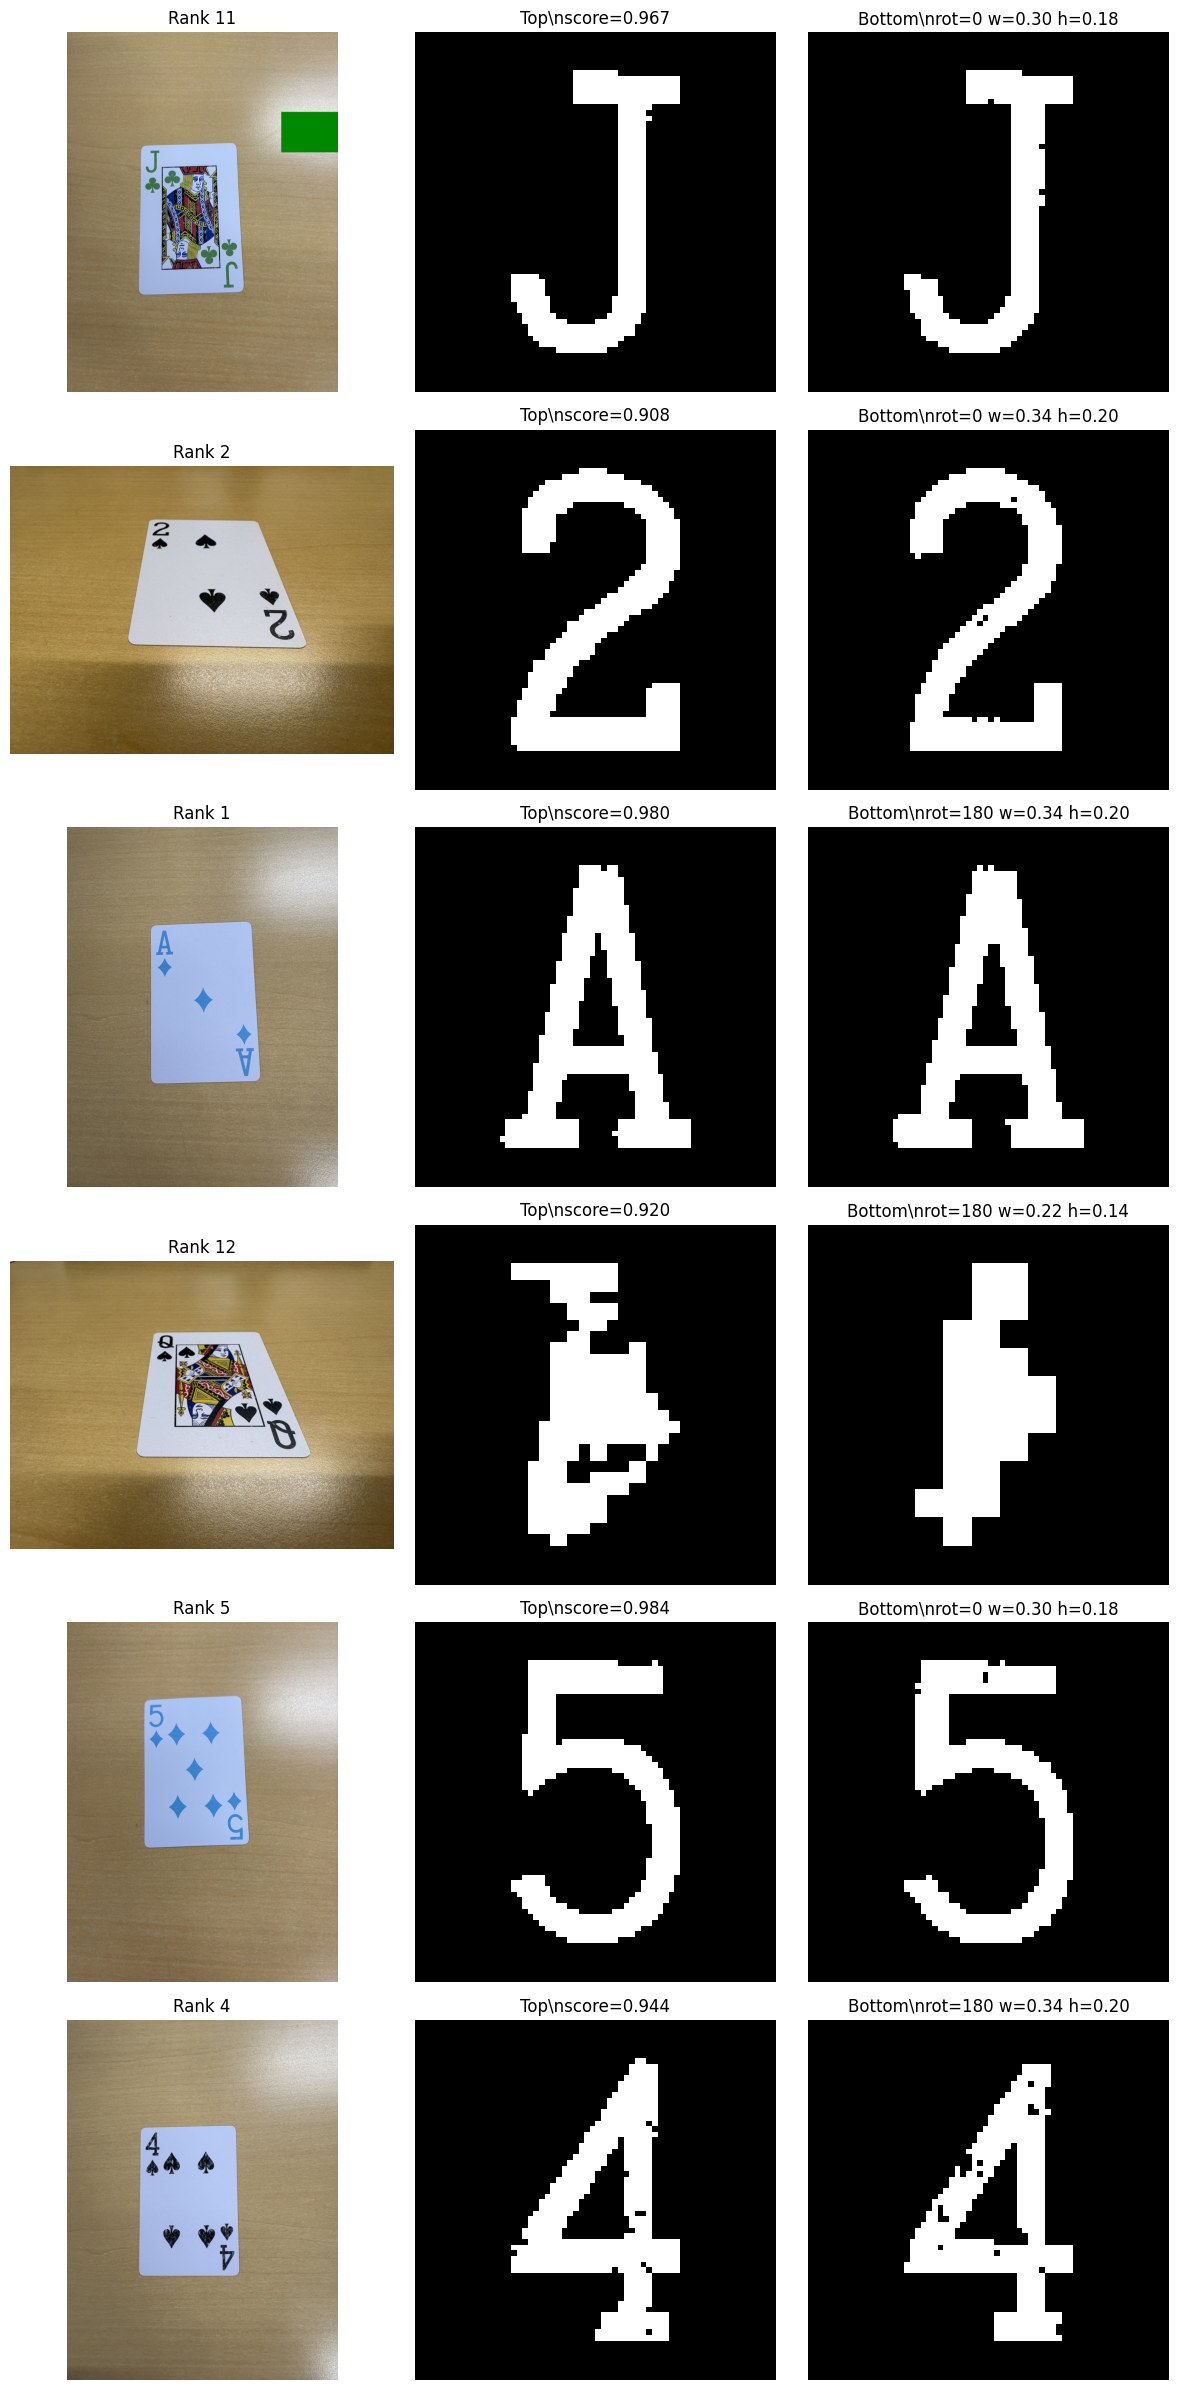

In [7]:
def prepare_multiscan_samples(
    input_samples,
    output_directory
):
    output_path = Path(
        output_directory
    )

    if output_path.exists():
        shutil.rmtree(
            output_path
        )

    output_path.mkdir(
        parents=True,
        exist_ok=True
    )

    processed_samples = []

    for sample_index, sample in enumerate(
        input_samples
    ):
        source_image = Image.open(
            sample["path"]
        ).convert("RGB")

        candidates = (
            extract_multiscan_rank_pairs(
                source_image
            )
        )

        sample_directory = (
            output_path
            / str(
                sample["rank"]
            )
            / f"{sample_index:04d}"
        )

        sample_directory.mkdir(
            parents=True,
            exist_ok=True
        )

        saved_candidates = []

        for candidate_index, candidate in enumerate(
            candidates
        ):
            top_path = (
                sample_directory
                / f"candidate_{candidate_index:02d}_top.png"
            )

            bottom_path = (
                sample_directory
                / f"candidate_{candidate_index:02d}_bottom.png"
            )

            Image.fromarray(
                candidate[
                    "top_image"
                ]
            ).save(
                top_path
            )

            Image.fromarray(
                candidate[
                    "bottom_image"
                ]
            ).save(
                bottom_path
            )

            saved_candidate = {
                key: value
                for key, value
                in candidate.items()
                if key
                not in [
                    "top_image",
                    "bottom_image"
                ]
            }

            saved_candidate[
                "top_path"
            ] = str(
                top_path
            )

            saved_candidate[
                "bottom_path"
            ] = str(
                bottom_path
            )

            saved_candidate[
                "quad"
            ] = (
                np.asarray(
                    saved_candidate[
                        "quad"
                    ]
                ).tolist()
            )

            saved_candidates.append(
                saved_candidate
            )

        processed_sample = dict(
            sample
        )

        processed_sample[
            "candidates"
        ] = saved_candidates

        processed_sample[
            "best_extraction_score"
        ] = float(
            saved_candidates[0][
                "score"
            ]
        )

        processed_samples.append(
            processed_sample
        )

        if (
            (sample_index + 1)
            % 5
            == 0
            or sample_index + 1
            == len(input_samples)
        ):
            print(
                f"多候補走査: "
                f"{sample_index + 1}/"
                f"{len(input_samples)}"
            )

    return processed_samples


samples = prepare_multiscan_samples(
    samples,
    PREPROCESSED_DIR
)

extraction_scores = np.array(
    [
        sample[
            "best_extraction_score"
        ]
        for sample in samples
    ],
    dtype=np.float64
)

print(
    "抽出品質："
)

print(
    f"最小: {extraction_scores.min():.3f}"
)

print(
    f"中央値: {np.median(extraction_scores):.3f}"
)

print(
    f"最大: {extraction_scores.max():.3f}"
)


# ==========================================
# ランダムな前処理結果
# ==========================================

preview_samples = random.sample(
    samples,
    k=min(
        6,
        len(samples)
    )
)

plt.figure(
    figsize=(
        12,
        4 * len(preview_samples)
    )
)

for row_index, sample in enumerate(
    preview_samples
):
    best_candidate = (
        sample[
            "candidates"
        ][0]
    )

    original = Image.open(
        sample["path"]
    ).convert("RGB")

    top_image = Image.open(
        best_candidate[
            "top_path"
        ]
    )

    bottom_image = Image.open(
        best_candidate[
            "bottom_path"
        ]
    )

    plt.subplot(
        len(preview_samples),
        3,
        row_index * 3 + 1
    )

    plt.imshow(
        original
    )

    plt.title(
        f"Rank {sample['rank']}"
    )

    plt.axis("off")


    plt.subplot(
        len(preview_samples),
        3,
        row_index * 3 + 2
    )

    plt.imshow(
        top_image,
        cmap="gray"
    )

    plt.title(
        "Top\\n"
        f"score={best_candidate['score']:.3f}"
    )

    plt.axis("off")


    plt.subplot(
        len(preview_samples),
        3,
        row_index * 3 + 3
    )

    plt.imshow(
        bottom_image,
        cmap="gray"
    )

    window = (
        best_candidate[
            "window"
        ]
    )

    plt.title(
        "Bottom\\n"
        f"rot={best_candidate['rotation']} "
        f"w={window['width_ratio']:.2f} "
        f"h={window['height_ratio']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


## 8. 抽出品質による学習データ選別

全体の品質分布から自動閾値を設定します。

原則として閾値未満の画像は学習に使用しません。ただし、クラス内の枚数が不足して交差検証できなくなる場合は、そのクラス内で品質が高い順に最低枚数まで追加し、強制採用として表示します。


In [8]:
percentile_threshold = float(
    np.percentile(
        extraction_scores,
        QUALITY_REJECTION_PERCENTILE
    )
)

quality_threshold = max(
    MIN_EXTRACTION_QUALITY,
    percentile_threshold
)

usable_indices = [
    index
    for index, sample
    in enumerate(samples)
    if sample[
        "best_extraction_score"
    ] >= quality_threshold
]

forced_indices = []

for class_id in range(
    NUM_CLASSES
):
    class_indices = [
        index
        for index, sample
        in enumerate(samples)
        if sample["label"]
        == class_id
    ]

    selected_class_indices = [
        index
        for index
        in usable_indices
        if samples[index][
            "label"
        ] == class_id
    ]

    if (
        len(selected_class_indices)
        < MIN_SAMPLES_PER_CLASS
    ):
        remaining = sorted(
            [
                index
                for index
                in class_indices
                if index
                not in usable_indices
            ],
            key=lambda index:
            samples[index][
                "best_extraction_score"
            ],
            reverse=True
        )

        number_needed = (
            MIN_SAMPLES_PER_CLASS
            - len(
                selected_class_indices
            )
        )

        additions = remaining[
            :number_needed
        ]

        usable_indices.extend(
            additions
        )

        forced_indices.extend(
            additions
        )

usable_indices = sorted(
    set(
        usable_indices
    )
)

forced_indices = sorted(
    set(
        forced_indices
    )
)

usable_samples = [
    samples[index]
    for index in usable_indices
]

usable_labels = np.array(
    [
        sample["label"]
        for sample
        in usable_samples
    ],
    dtype=np.int64
)

usable_groups = np.array(
    [
        sample["suit"]
        for sample
        in usable_samples
    ]
)

print(
    f"品質閾値: "
    f"{quality_threshold:.3f}"
)

print(
    f"学習候補画像: "
    f"{len(usable_samples)}/"
    f"{len(samples)}"
)

print(
    f"強制採用画像: "
    f"{len(forced_indices)}"
)

for index in forced_indices:
    print(
        "強制採用:",
        samples[index]["path"],
        f"score="
        f"{samples[index]['best_extraction_score']:.3f}"
    )

print(
    "\nクラス別採用枚数"
)

for class_id in range(
    NUM_CLASSES
):
    count = int(
        np.sum(
            usable_labels
            == class_id
        )
    )

    print(
        f"Rank {class_id + 1:2d}: "
        f"{count}枚"
    )


品質閾値: 0.900
学習候補画像: 88/104
強制採用画像: 0

クラス別採用枚数
Rank  1: 8枚
Rank  2: 7枚
Rank  3: 7枚
Rank  4: 8枚
Rank  5: 7枚
Rank  6: 8枚
Rank  7: 6枚
Rank  8: 5枚
Rank  9: 6枚
Rank 10: 7枚
Rank 11: 7枚
Rank 12: 4枚
Rank 13: 8枚


## 9. HOG特徴量と正しい抽出画像だけの水増し

水増しは、抽出品質を通過した学習側データにだけ適用します。

適用する変形は、正規化後に残り得る小さな差だけです。

- ±3度の回転
- ±1～2画素の移動
- 1回の膨張・収縮
- 弱いぼかし

大きな角度変化や強い射影変形は、誤った文字形状を作るため使用しません。


In [9]:
def load_binary(path):
    image = Image.open(
        path
    ).convert("L")

    array = np.array(
        image,
        dtype=np.uint8
    )

    _, binary = cv2.threshold(
        array,
        127,
        255,
        cv2.THRESH_BINARY
    )

    return binary


def translate_binary(
    image,
    x_shift,
    y_shift
):
    matrix = np.float32(
        [
            [
                1,
                0,
                x_shift
            ],
            [
                0,
                1,
                y_shift
            ]
        ]
    )

    return cv2.warpAffine(
        image,
        matrix,
        (
            image.shape[1],
            image.shape[0]
        ),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )


def rotate_binary(
    image,
    angle
):
    height, width = (
        image.shape
    )

    matrix = (
        cv2.getRotationMatrix2D(
            (
                width / 2.0,
                height / 2.0
            ),
            angle,
            1.0
        )
    )

    return cv2.warpAffine(
        image,
        matrix,
        (
            width,
            height
        ),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )


def create_augmented_images(
    image
):
    if not USE_AUGMENTATION:
        return [
            image
        ]

    kernel = np.ones(
        (2, 2),
        dtype=np.uint8
    )

    variants = [
        image,
        rotate_binary(
            image,
            -3
        ),
        rotate_binary(
            image,
            3
        ),
        translate_binary(
            image,
            -2,
            0
        ),
        translate_binary(
            image,
            2,
            0
        ),
        translate_binary(
            image,
            0,
            -2
        ),
        translate_binary(
            image,
            0,
            2
        ),
        cv2.dilate(
            image,
            kernel,
            iterations=1
        ),
        cv2.erode(
            image,
            kernel,
            iterations=1
        ),
        cv2.GaussianBlur(
            image,
            (3, 3),
            0
        )
    ]

    normalized = []

    for variant in variants:
        _, binary = cv2.threshold(
            variant,
            127,
            255,
            cv2.THRESH_BINARY
        )

        normalized.append(
            fit_binary_to_canvas(
                binary,
                output_size=(
                    HOG_IMAGE_SIZE
                ),
                target_size=50
            )
        )

    return normalized


def extract_shape_features(
    image
):
    image = image.astype(
        np.uint8
    )

    hog_feature = (
        HOG_DESCRIPTOR
        .compute(
            image
        )
        .reshape(-1)
        .astype(
            np.float32
        )
    )

    float_image = (
        image.astype(
            np.float32
        )
        / 255.0
    )

    horizontal_projection = (
        float_image.mean(
            axis=1
        )
    )

    vertical_projection = (
        float_image.mean(
            axis=0
        )
    )

    pixel_feature = cv2.resize(
        float_image,
        (
            24,
            24
        ),
        interpolation=cv2.INTER_AREA
    ).reshape(-1)

    moments = cv2.moments(
        image
    )

    hu_moments = (
        cv2.HuMoments(
            moments
        )
        .reshape(-1)
    )

    hu_moments = (
        -np.sign(
            hu_moments
        )
        * np.log10(
            np.abs(
                hu_moments
            )
            + 1.0e-12
        )
    ).astype(
        np.float32
    )

    occupancy = np.array(
        [
            float_image.mean(),
            float_image[
                :32,
                :
            ].mean(),
            float_image[
                32:,
                :
            ].mean(),
            float_image[
                :,
                :32
            ].mean(),
            float_image[
                :,
                32:
            ].mean()
        ],
        dtype=np.float32
    )

    return np.concatenate(
        [
            hog_feature,
            horizontal_projection.astype(
                np.float32
            ),
            vertical_projection.astype(
                np.float32
            ),
            pixel_feature.astype(
                np.float32
            ),
            hu_moments,
            occupancy
        ]
    )


test_feature = (
    extract_shape_features(
        load_binary(
            usable_samples[0][
                "candidates"
            ][0][
                "top_path"
            ]
        )
    )
)

print(
    "特徴量次元数:",
    test_feature.shape[0]
)


特徴量次元数: 2480


## 10. SVM・テンプレート照合・候補選択

学習時は、最良候補との差が小さい上位抽出候補も使用します。ただし同じ元カード由来の候補は、交差検証で必ず同じfoldに入ります。

推論時は各抽出候補について分類を行い、次の総合点が最大の候補を採用します。

```text
分類確信度 × 0.55
＋ 1位と2位の差 × 0.20
＋ 抽出品質 × 0.25
```


In [10]:
def build_svm_model():
    return Pipeline(
        [
            (
                "scaler",
                StandardScaler()
            ),
            (
                "svm",
                SVC(
                    kernel=SVM_KERNEL,
                    C=SVM_C,
                    gamma=SVM_GAMMA,
                    probability=True,
                    class_weight="balanced",
                    random_state=SEED
                )
            )
        ]
    )


def training_candidates_for_sample(
    sample
):
    best_score = (
        sample[
            "candidates"
        ][0][
            "score"
        ]
    )

    selected = []

    for candidate in sample[
        "candidates"
    ]:
        if (
            len(selected)
            >= MAX_ALTERNATIVE_CANDIDATES_FOR_TRAIN
        ):
            break

        if (
            candidate[
                "score"
            ]
            < quality_threshold
        ):
            continue

        if (
            best_score
            - candidate[
                "score"
            ]
            > ALTERNATIVE_CANDIDATE_SCORE_GAP
        ):
            continue

        selected.append(
            candidate
        )

    if len(selected) == 0:
        selected.append(
            sample[
                "candidates"
            ][0]
        )

    return selected


def create_training_matrix(
    training_samples
):
    feature_rows = []
    label_rows = []

    for sample in training_samples:
        candidates = (
            training_candidates_for_sample(
                sample
            )
        )

        for candidate in candidates:
            for side_key in [
                "top_path",
                "bottom_path"
            ]:
                image = load_binary(
                    candidate[
                        side_key
                    ]
                )

                for augmented in (
                    create_augmented_images(
                        image
                    )
                ):
                    feature_rows.append(
                        extract_shape_features(
                            augmented
                        )
                    )

                    label_rows.append(
                        sample[
                            "label"
                        ]
                    )

    return (
        np.asarray(
            feature_rows,
            dtype=np.float32
        ),
        np.asarray(
            label_rows,
            dtype=np.int64
        )
    )


def build_template_bank(
    training_samples
):
    template_bank = {
        class_id: []
        for class_id in range(
            NUM_CLASSES
        )
    }

    for sample in training_samples:
        for candidate in (
            training_candidates_for_sample(
                sample
            )
        ):
            for side_key in [
                "top_path",
                "bottom_path"
            ]:
                template_bank[
                    sample[
                        "label"
                    ]
                ].append(
                    load_binary(
                        candidate[
                            side_key
                        ]
                    ).astype(
                        np.float32
                    ) / 255.0
                )

    return template_bank


def fit_classical_model(
    training_samples
):
    features, training_labels = (
        create_training_matrix(
            training_samples
        )
    )

    model = build_svm_model()

    model.fit(
        features,
        training_labels
    )

    return {
        "svm_model": model,
        "template_bank": (
            build_template_bank(
                training_samples
            )
        ),
        "number_of_training_vectors": (
            len(
                training_labels
            )
        )
    }


def softmax_numpy(
    values,
    temperature=1.0
):
    values = np.asarray(
        values,
        dtype=np.float64
    )

    shifted = (
        values
        - values.max()
    ) / max(
        float(
            temperature
        ),
        1.0e-6
    )

    exponential = np.exp(
        np.clip(
            shifted,
            -60,
            60
        )
    )

    return (
        exponential
        / exponential.sum()
    )


def template_probabilities(
    image,
    template_bank
):
    query = (
        image.astype(
            np.float32
        ) / 255.0
    )

    class_scores = []

    for class_id in range(
        NUM_CLASSES
    ):
        similarities = [
            normalized_correlation(
                query,
                template
            )
            for template
            in template_bank[
                class_id
            ]
        ]

        if len(similarities) == 0:
            class_scores.append(
                -1.0
            )
            continue

        similarities = sorted(
            similarities,
            reverse=True
        )

        top_values = similarities[
            :min(
                TEMPLATE_TOP_K,
                len(
                    similarities
                )
            )
        ]

        class_scores.append(
            float(
                np.mean(
                    top_values
                )
            )
        )

    return softmax_numpy(
        class_scores,
        temperature=(
            TEMPLATE_TEMPERATURE
        )
    )


def side_probabilities(
    image,
    model_bundle
):
    feature = (
        extract_shape_features(
            image
        ).reshape(
            1,
            -1
        )
    )

    svm_model = model_bundle[
        "svm_model"
    ]

    partial_probability = (
        svm_model.predict_proba(
            feature
        )[0]
    )

    svm_probability = np.zeros(
        NUM_CLASSES,
        dtype=np.float64
    )

    for position, class_id in enumerate(
        svm_model.classes_
    ):
        svm_probability[
            int(class_id)
        ] = partial_probability[
            position
        ]

    template_probability = (
        template_probabilities(
            image,
            model_bundle[
                "template_bank"
            ]
        )
    )

    combined = (
        SVM_WEIGHT
        * svm_probability
        + TEMPLATE_WEIGHT
        * template_probability
    )

    combined = (
        combined
        / combined.sum()
    )

    return combined


def classify_extraction_candidate(
    candidate,
    model_bundle
):
    top_image = load_binary(
        candidate[
            "top_path"
        ]
    )

    bottom_image = load_binary(
        candidate[
            "bottom_path"
        ]
    )

    top_probability = (
        side_probabilities(
            top_image,
            model_bundle
        )
    )

    bottom_probability = (
        side_probabilities(
            bottom_image,
            model_bundle
        )
    )

    top_weight = (
        TOP_BASE_WEIGHT
        * max(
            candidate[
                "top_quality"
            ],
            0.10
        )
    )

    bottom_weight = (
        BOTTOM_BASE_WEIGHT
        * max(
            candidate[
                "bottom_quality"
            ],
            0.10
        )
    )

    weight_sum = max(
        top_weight
        + bottom_weight,
        1.0e-8
    )

    fused_probability = (
        top_weight
        * top_probability
        + bottom_weight
        * bottom_probability
    ) / weight_sum

    order = np.argsort(
        fused_probability
    )[::-1]

    confidence = float(
        fused_probability[
            order[0]
        ]
    )

    margin = float(
        fused_probability[
            order[0]
        ]
        - fused_probability[
            order[1]
        ]
    )

    candidate_selection_score = (
        CLASSIFIER_CONFIDENCE_WEIGHT
        * confidence
        + CLASSIFIER_MARGIN_WEIGHT
        * margin
        + EXTRACTION_SCORE_WEIGHT
        * candidate[
            "score"
        ]
    )

    return {
        "prediction": int(
            order[0]
        ),
        "probability": (
            fused_probability
        ),
        "confidence": (
            confidence
        ),
        "margin": (
            margin
        ),
        "selection_score": float(
            candidate_selection_score
        ),
        "top_prediction": int(
            np.argmax(
                top_probability
            )
        ),
        "bottom_prediction": int(
            np.argmax(
                bottom_probability
            )
        ),
        "top_weight": float(
            top_weight
            / weight_sum
        ),
        "bottom_weight": float(
            bottom_weight
            / weight_sum
        ),
        "candidate": candidate
    }


def predict_sample(
    sample,
    model_bundle
):
    evaluated_candidates = [
        classify_extraction_candidate(
            candidate,
            model_bundle
        )
        for candidate
        in sample[
            "candidates"
        ]
    ]

    evaluated_candidates.sort(
        key=lambda item:
        item[
            "selection_score"
        ],
        reverse=True
    )

    best = (
        evaluated_candidates[0]
    )

    accepted = (
        best[
            "confidence"
        ] >= CONFIDENCE_THRESHOLD
        and best[
            "margin"
        ] >= MARGIN_THRESHOLD
        and best[
            "candidate"
        ][
            "score"
        ] >= EXTRACTION_ACCEPT_THRESHOLD
    )

    best[
        "accepted"
    ] = accepted

    best[
        "all_evaluated_candidates"
    ] = evaluated_candidates

    return best


## 11. 交差検証

In [11]:
minimum_class_count = int(
    np.min(
        np.bincount(
            usable_labels
        )
    )
)

if CV_MODE == "suit_group":
    valid_groups = sorted(
        set(
            usable_groups.tolist()
        )
        - {"unknown"}
    )

    if len(valid_groups) < 2:
        print(
            "スートを十分に取得できないため、"
            "stratifiedへ変更します。"
        )

        CV_MODE = "stratified"

    else:
        number_of_splits = min(
            4,
            len(
                valid_groups
            )
        )

        splitter = (
            StratifiedGroupKFold(
                n_splits=(
                    number_of_splits
                ),
                shuffle=True,
                random_state=SEED
            )
        )

        split_iterator = (
            splitter.split(
                np.zeros(
                    len(
                        usable_samples
                    )
                ),
                usable_labels,
                usable_groups
            )
        )

if CV_MODE == "stratified":
    number_of_splits = min(
        REQUESTED_SPLITS,
        minimum_class_count
    )

    splitter = StratifiedKFold(
        n_splits=number_of_splits,
        shuffle=True,
        random_state=SEED
    )

    split_iterator = splitter.split(
        np.zeros(
            len(
                usable_samples
            )
        ),
        usable_labels
    )

splits = list(
    split_iterator
)

print("CV mode:", CV_MODE)
print("Fold数:", len(splits))

oof_predictions = np.full(
    len(
        usable_samples
    ),
    -1,
    dtype=np.int64
)

oof_probabilities = np.zeros(
    (
        len(
            usable_samples
        ),
        NUM_CLASSES
    ),
    dtype=np.float64
)

oof_accepted = np.zeros(
    len(
        usable_samples
    ),
    dtype=bool
)

oof_confidence = np.zeros(
    len(
        usable_samples
    ),
    dtype=np.float64
)

oof_margin = np.zeros(
    len(
        usable_samples
    ),
    dtype=np.float64
)

oof_extraction_score = np.zeros(
    len(
        usable_samples
    ),
    dtype=np.float64
)

oof_selected_candidate_index = np.full(
    len(
        usable_samples
    ),
    -1,
    dtype=np.int64
)

fold_accuracies = []


for fold_index, (
    train_indices,
    validation_indices
) in enumerate(
    splits,
    start=1
):
    print(
        "\n"
        + "=" * 60
    )

    print(
        f"Fold {fold_index}/"
        f"{len(splits)}"
    )

    training_samples = [
        usable_samples[index]
        for index in train_indices
    ]

    validation_samples = [
        usable_samples[index]
        for index in validation_indices
    ]

    model_bundle = (
        fit_classical_model(
            training_samples
        )
    )

    print(
        "学習ベクトル数:",
        model_bundle[
            "number_of_training_vectors"
        ]
    )

    fold_true = []
    fold_predicted = []

    for local_index, (
        global_index,
        sample
    ) in enumerate(
        zip(
            validation_indices,
            validation_samples
        )
    ):
        result = predict_sample(
            sample,
            model_bundle
        )

        oof_predictions[
            global_index
        ] = result[
            "prediction"
        ]

        oof_probabilities[
            global_index
        ] = result[
            "probability"
        ]

        oof_accepted[
            global_index
        ] = result[
            "accepted"
        ]

        oof_confidence[
            global_index
        ] = result[
            "confidence"
        ]

        oof_margin[
            global_index
        ] = result[
            "margin"
        ]

        oof_extraction_score[
            global_index
        ] = result[
            "candidate"
        ][
            "score"
        ]

        selected_candidate = (
            result[
                "candidate"
            ]
        )

        for candidate_index, candidate in enumerate(
            sample[
                "candidates"
            ]
        ):
            if (
                candidate[
                    "top_path"
                ]
                == selected_candidate[
                    "top_path"
                ]
                and candidate[
                    "bottom_path"
                ]
                == selected_candidate[
                    "bottom_path"
                ]
            ):
                oof_selected_candidate_index[
                    global_index
                ] = candidate_index
                break

        fold_true.append(
            sample[
                "label"
            ]
        )

        fold_predicted.append(
            result[
                "prediction"
            ]
        )

    fold_accuracy = (
        accuracy_score(
            fold_true,
            fold_predicted
        )
        * 100.0
    )

    fold_accuracies.append(
        fold_accuracy
    )

    print(
        f"Fold accuracy: "
        f"{fold_accuracy:.2f}%"
    )


CV mode: stratified
Fold数: 4

Fold 1/4
学習ベクトル数: 3540
Fold accuracy: 68.18%

Fold 2/4
学習ベクトル数: 3580
Fold accuracy: 86.36%

Fold 3/4
学習ベクトル数: 3620
Fold accuracy: 68.18%

Fold 4/4
学習ベクトル数: 3540
Fold accuracy: 90.91%


## 12. 評価結果

Fold accuracies: [68.18, 86.36, 68.18, 90.91]
Mean fold accuracy: 78.41%
Standard deviation: 10.35%
Overall accuracy: 78.41%
Accepted coverage: 96.59%
Accepted accuracy: 80.00%
第2候補以降が採用された割合: 47.73%
平均採用抽出品質: 0.940


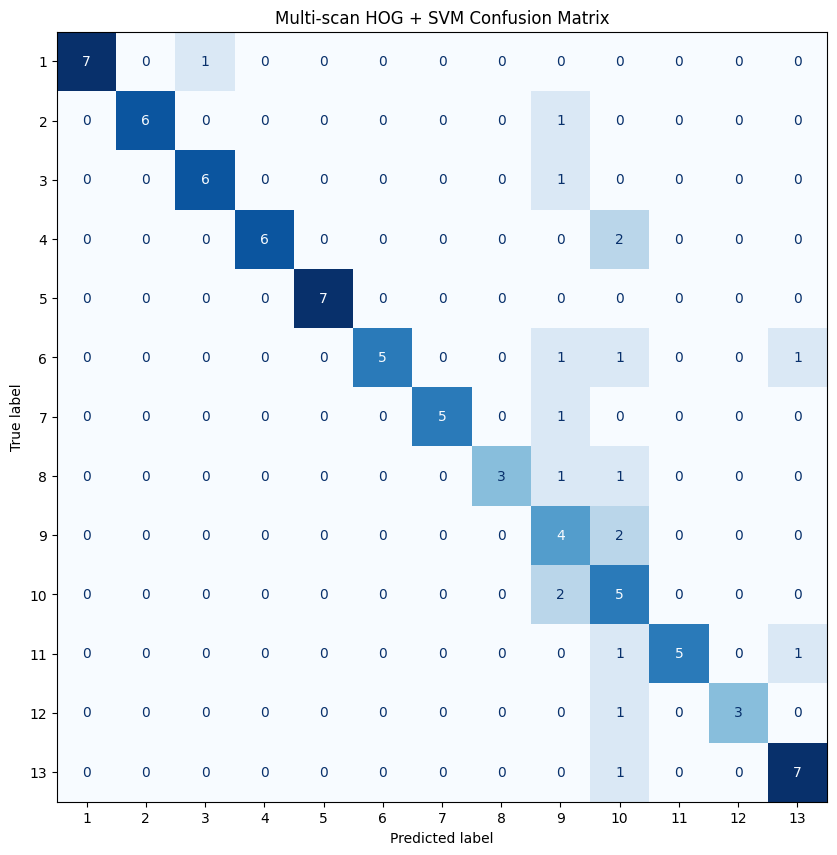

In [12]:
if np.any(
    oof_predictions < 0
):
    raise RuntimeError(
        "未評価画像があります。"
    )

overall_accuracy = (
    accuracy_score(
        usable_labels,
        oof_predictions
    )
    * 100.0
)

coverage = (
    np.mean(
        oof_accepted
    )
    * 100.0
)

if np.any(
    oof_accepted
):
    accepted_accuracy = (
        accuracy_score(
            usable_labels[
                oof_accepted
            ],
            oof_predictions[
                oof_accepted
            ]
        )
        * 100.0
    )
else:
    accepted_accuracy = 0.0

non_first_candidate_rate = (
    np.mean(
        oof_selected_candidate_index
        > 0
    )
    * 100.0
)

print(
    "Fold accuracies:",
    [
        round(
            value,
            2
        )
        for value
        in fold_accuracies
    ]
)

print(
    f"Mean fold accuracy: "
    f"{np.mean(fold_accuracies):.2f}%"
)

print(
    f"Standard deviation: "
    f"{np.std(fold_accuracies):.2f}%"
)

print(
    f"Overall accuracy: "
    f"{overall_accuracy:.2f}%"
)

print(
    f"Accepted coverage: "
    f"{coverage:.2f}%"
)

print(
    f"Accepted accuracy: "
    f"{accepted_accuracy:.2f}%"
)

print(
    f"第2候補以降が採用された割合: "
    f"{non_first_candidate_rate:.2f}%"
)

print(
    f"平均採用抽出品質: "
    f"{oof_extraction_score.mean():.3f}"
)


matrix = confusion_matrix(
    usable_labels,
    oof_predictions,
    labels=list(
        range(
            NUM_CLASSES
        )
    )
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[
        str(rank)
        for rank in range(
            1,
            14
        )
    ]
)

figure, axis = plt.subplots(
    figsize=(
        10,
        10
    )
)

display.plot(
    ax=axis,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Multi-scan HOG + SVM "
    "Confusion Matrix"
)

plt.show()


## 13. 抽出失敗・誤分類の診断

誤分類画像について、実際に分類へ使用された候補を表示します。

前版と異なり、第1候補以外が選ばれた場合も候補番号を確認できます。


In [13]:
misclassified_indices = np.where(
    usable_labels
    != oof_predictions
)[0]

print(
    "誤分類数:",
    len(
        misclassified_indices
    )
)

display_count = min(
    15,
    len(
        misclassified_indices
    )
)

if display_count > 0:
    sorted_indices = sorted(
        misclassified_indices,
        key=lambda index:
        oof_confidence[
            index
        ],
        reverse=True
    )[:display_count]

    plt.figure(
        figsize=(
            12,
            4 * display_count
        )
    )

    for row_index, usable_index in enumerate(
        sorted_indices
    ):
        sample = usable_samples[
            usable_index
        ]

        candidate_index = int(
            oof_selected_candidate_index[
                usable_index
            ]
        )

        candidate = sample[
            "candidates"
        ][
            candidate_index
        ]

        original = Image.open(
            sample["path"]
        ).convert("RGB")

        top_image = Image.open(
            candidate[
                "top_path"
            ]
        )

        bottom_image = Image.open(
            candidate[
                "bottom_path"
            ]
        )

        probability = (
            oof_probabilities[
                usable_index
            ]
        )

        top_three_indices = (
            np.argsort(
                probability
            )[::-1][:3]
        )

        top_three = [
            (
                int(
                    class_index
                    + 1
                ),
                round(
                    float(
                        probability[
                            class_index
                        ]
                    ) * 100,
                    1
                )
            )
            for class_index
            in top_three_indices
        ]

        true_rank = (
            usable_labels[
                usable_index
            ]
            + 1
        )

        predicted_rank = (
            oof_predictions[
                usable_index
            ]
            + 1
        )

        plt.subplot(
            display_count,
            3,
            row_index * 3 + 1
        )

        plt.imshow(
            original
        )

        plt.title(
            f"True {true_rank} / "
            f"Pred {predicted_rank}\n"
            f"Candidate {candidate_index + 1} "
            f"Conf "
            f"{oof_confidence[usable_index] * 100:.1f}%"
        )

        plt.axis("off")


        plt.subplot(
            display_count,
            3,
            row_index * 3 + 2
        )

        plt.imshow(
            top_image,
            cmap="gray"
        )

        plt.title(
            f"Top "
            f"score={candidate['score']:.3f}\n"
            f"sim={candidate['similarity']:.3f}"
        )

        plt.axis("off")


        plt.subplot(
            display_count,
            3,
            row_index * 3 + 3
        )

        plt.imshow(
            bottom_image,
            cmap="gray"
        )

        plt.title(
            f"Bottom\n"
            f"rot={candidate['rotation']} "
            f"Top3={top_three}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


# 抽出品質の低い画像
worst_indices = np.argsort(
    [
        sample[
            "best_extraction_score"
        ]
        for sample
        in samples
    ]
)[:min(
    12,
    len(samples)
)]

print(
    "\n抽出品質が低い画像:"
)

for index in worst_indices:
    print(
        f"score="
        f"{samples[index]['best_extraction_score']:.3f}",
        samples[index]["path"]
    )


Output hidden; open in https://colab.research.google.com to view.

## 14. 全採用データで最終モデルを作成

交差検証終了後、抽出品質を通過したすべてのデータで実運用モデルを作成します。


In [14]:
final_model_bundle = (
    fit_classical_model(
        usable_samples
    )
)

save_bundle = {
    "svm_model": (
        final_model_bundle[
            "svm_model"
        ]
    ),
    "template_bank": (
        final_model_bundle[
            "template_bank"
        ]
    ),
    "num_classes": (
        NUM_CLASSES
    ),
    "class_names": [
        str(rank)
        for rank in range(
            1,
            14
        )
    ],
    "quality_threshold": float(
        quality_threshold
    ),
    "overall_accuracy": float(
        overall_accuracy
    ),
    "accepted_coverage": float(
        coverage
    ),
    "accepted_accuracy": float(
        accepted_accuracy
    ),
    "number_of_usable_images": int(
        len(
            usable_samples
        )
    ),
    "number_of_training_vectors": int(
        final_model_bundle[
            "number_of_training_vectors"
        ]
    ),
    "scan_window_sizes": (
        SCAN_WINDOW_SIZES
    ),
    "scan_offsets": (
        SCAN_OFFSETS
    ),
    "model_version": (
        "multi_scan_hog_svm_v2"
    )
}

joblib.dump(
    save_bundle,
    MODEL_PATH
)

print(
    "保存しました:",
    MODEL_PATH
)

print(
    "最終学習画像数:",
    len(
        usable_samples
    )
)

print(
    "最終学習ベクトル数:",
    final_model_bundle[
        "number_of_training_vectors"
    ]
)


保存しました: /content/drive/MyDrive/Colab Notebooks/AIseminar/rank_multiscan_hog_svm_v2.joblib
最終学習画像数: 88
最終学習ベクトル数: 4760


## 15. 未知画像の推論

未知画像でも同じ多候補走査を実行し、抽出品質と分類確信度を合わせて最終候補を選びます。


In [15]:
def prepare_unknown_sample(
    image_path
):
    source_image = Image.open(
        image_path
    ).convert("RGB")

    candidates = (
        extract_multiscan_rank_pairs(
            source_image
        )
    )

    temporary_directory = Path(
        "/content/"
        "unknown_multiscan_candidates"
    )

    if temporary_directory.exists():
        shutil.rmtree(
            temporary_directory
        )

    temporary_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    saved_candidates = []

    for candidate_index, candidate in enumerate(
        candidates
    ):
        top_path = (
            temporary_directory
            / f"{candidate_index:02d}_top.png"
        )

        bottom_path = (
            temporary_directory
            / f"{candidate_index:02d}_bottom.png"
        )

        Image.fromarray(
            candidate[
                "top_image"
            ]
        ).save(
            top_path
        )

        Image.fromarray(
            candidate[
                "bottom_image"
            ]
        ).save(
            bottom_path
        )

        saved = {
            key: value
            for key, value
            in candidate.items()
            if key not in [
                "top_image",
                "bottom_image"
            ]
        }

        saved[
            "top_path"
        ] = str(
            top_path
        )

        saved[
            "bottom_path"
        ] = str(
            bottom_path
        )

        saved[
            "quad"
        ] = (
            np.asarray(
                saved["quad"]
            ).tolist()
        )

        saved_candidates.append(
            saved
        )

    return {
        "path": str(
            image_path
        ),
        "candidates": (
            saved_candidates
        ),
        "best_extraction_score": (
            saved_candidates[0][
                "score"
            ]
        )
    }


def predict_unknown_image(
    image_path,
    model_bundle=final_model_bundle
):
    sample = (
        prepare_unknown_sample(
            image_path
        )
    )

    result = predict_sample(
        sample,
        model_bundle
    )

    predicted_rank = (
        result[
            "prediction"
        ]
        + 1
    )

    candidate = result[
        "candidate"
    ]

    probability = result[
        "probability"
    ]

    top_indices = np.argsort(
        probability
    )[::-1][:3]

    top_three = [
        (
            int(
                class_index
                + 1
            ),
            round(
                float(
                    probability[
                        class_index
                    ]
                ) * 100,
                2
            )
        )
        for class_index
        in top_indices
    ]

    print(
        "Prediction:",
        predicted_rank
        if result[
            "accepted"
        ]
        else "判定保留"
    )

    print(
        "Best candidate:",
        predicted_rank
    )

    print(
        f"Confidence: "
        f"{result['confidence'] * 100:.2f}%"
    )

    print(
        f"Margin: "
        f"{result['margin'] * 100:.2f}%"
    )

    print(
        f"Extraction score: "
        f"{candidate['score']:.3f}"
    )

    print(
        "Top 3:",
        top_three
    )

    print(
        "Card detector:",
        candidate[
            "quad_method"
        ]
    )

    print(
        "Rotation:",
        candidate[
            "rotation"
        ]
    )

    print(
        "Window:",
        candidate[
            "window"
        ]
    )

    original = Image.open(
        image_path
    ).convert("RGB")

    top_image = Image.open(
        candidate[
            "top_path"
        ]
    )

    bottom_image = Image.open(
        candidate[
            "bottom_path"
        ]
    )

    plt.figure(
        figsize=(
            12,
            4
        )
    )

    plt.subplot(
        1,
        3,
        1
    )

    plt.imshow(
        original
    )

    plt.title("Original")
    plt.axis("off")


    plt.subplot(
        1,
        3,
        2
    )

    plt.imshow(
        top_image,
        cmap="gray"
    )

    plt.title(
        f"Top → "
        f"{result['top_prediction'] + 1}"
    )

    plt.axis("off")


    plt.subplot(
        1,
        3,
        3
    )

    plt.imshow(
        bottom_image,
        cmap="gray"
    )

    plt.title(
        f"Bottom → "
        f"{result['bottom_prediction'] + 1}"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return result


# 使用例
# UNKNOWN_IMAGE_PATH = (
#     "/content/drive/MyDrive/"
#     "Colab Notebooks/AIseminar/"
#     "unknown.jpg"
# )
#
# predict_unknown_image(
#     UNKNOWN_IMAGE_PATH
# )


## 結果の見方

- **第2候補以降が採用された割合**  
  多候補走査が実際に抽出ミスを修正した割合の目安です。

- **抽出品質が低い画像**  
  ランク文字を安定して取得できていない可能性があります。元画像、カード外周、照明を確認してください。

- **Accepted Accuracy**  
  抽出品質・分類確信度が基準を満たした画像だけのAccuracyです。

- **水増しについて**  
  この版では、抽出品質を通過した学習側画像だけを水増しします。元カード単位で交差検証を分割した後に生成するため、同じ元画像の変形が評価側へ漏れることはありません。

- **実画像追加との違い**  
  水増しは小さな位置・角度・線幅の変化には有効ですが、別書体、実際の反射、別背景、ピンぼけ、異なる撮影機器は再現できません。精度の上限を上げるには、撮影条件を変えた実画像の追加も必要です。
